#Практическая работа №1


**Цель работы** – провести первичный анализ данных. Необходимо выявить особенности датасета, оценить качество данных, обработать пропуски, выбросы и ошибки в типах данных.

**Задачи:**

1. Изучить структуру данных: размерность, признаки, типы данных, наличие пропусков.
2. Обработать неправильные типы данных.
3. Обработать пропуски: заполнить статистическими методами (например, медианой или модой), удалить, либо создать отдельную категорию.
4. Обработать выбросы: выявить аномальные значения и скорректировать их (удаление, обрезка или трансформация).
5. Преобразовать категориальные признаки: бинарное кодирование или OneHot-кодирование для многозначных категорий.
6. Разделить данные на обучающую, валидационную и тестовую выборки.
7. Выполнить стандартизацию числовых признаков.
8. Построить визуализации для наглядного анализа (гистограммы, boxplot, корреляционная матрица и др.).
9. Сделать выводы по каждому этапу и общий вывод о данных.

**Описание признаков датасета**

Для работы я выбрала датасет Rain in Australia https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package. Набор данных содержит ежедневные метеорологические наблюдения за 10 лет из многочисленных мест по всей Австралии. Прогнозируемая переменная - дождь на завтра. Она отвечает на важнейший вопрос: будет ли дождь на следующий день? (Да или нет).

Датасет включает такие признаки:

* Date — дата наблюдения.
* Location — название местоположения метеостанции.
* MinTemp, MaxTemp — минимальная и максимальная температура в градусах Цельсия.
* Rainfall — количество осадков, зафиксированных за день (мм).
* Evaporation — испарение по классу A (мм) за 24 часа до 9 утра.
* Sunshine — количество часов яркого солнечного света в течение дня.
* WindGustDir — направление самого сильного порыва ветра в течение 24 часов до полуночи.
* WindGustSpeed — скорость (км/ч) самого сильного порыва ветра в течение 24 часов до полуночи.
* WindDir9am, WindDir3pm — направление ветра в 9 утра и в 3 дня.
* WindSpeed9am, WindSpeed3pm — средняя скорость ветра (км/ч) за 10 минут до 9 утра и до 3 дня.
* Humidity9am, Humidity3pm — влажность воздуха (%) в 9 утра и в 3 дня.
* Pressure9am, Pressure3pm — атмосферное давление (hPa) в 9 утра и в 3 дня.
* Cloud9am, Cloud3pm — доля неба, закрытая облаками, в 9 утра и в 3 дня. Измеряется: 0 — полностью ясное небо, 8 — полностью затянутое.
* Temp9am, Temp3pm — температура (°C) в 9 утра и в 3 дня.
* RainToday — булевый признак: 1, если количество осадков (мм) за 24 часа до 9 утра превышает 1 мм, иначе 0.
* RainTomorrow — количество осадков на следующий день (мм). Используется для формирования целевой переменной RainTomorrow — индикатора «будет дождь завтра или нет».


Использованные в работе библиотеки:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## 1. Загрузка и первичный анализ данных

In [2]:
# Чтение данных
url = "https://raw.githubusercontent.com/GusevaVarvara/Weather-dataset/refs/heads/main/weatherAUS.csv"
data = pd.read_csv(url)

In [3]:
# Размер и названия колонок
print("\nРазмер данных (строки, столбцы):", data.shape)
print("Названия столбцов:", data.columns.tolist())


Размер данных (строки, столбцы): (145460, 23)
Названия столбцов: ['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow']


In [4]:
# Первые строки датасета
data.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [5]:
# Случайные строки датасета
data.sample(5)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
101017,2013-04-12,MountGambier,6.5,28.6,0.0,0.4,7.4,NW,33.0,N,...,72.0,24.0,1022.3,1017.2,2.0,8.0,16.9,28.2,No,No
23724,2016-05-18,NorfolkIsland,15.9,22.4,0.0,3.2,NaN,NE,20.0,E,...,64.0,71.0,1021.0,1017.9,NaN,8.0,21.0,20.5,No,No
54689,2016-05-09,MountGinini,7.6,10.7,50.8,NaN,NaN,WNW,78.0,NNW,...,97.0,97.0,NaN,NaN,NaN,NaN,10.0,10.2,Yes,Yes
33976,2010-04-02,SydneyAirport,17.2,22.2,0.0,5.8,9.4,S,46.0,SSW,...,64.0,58.0,1020.0,1018.6,6.0,1.0,20.0,21.6,No,No
53817,2013-12-19,MountGinini,12.7,25.4,0.0,NaN,NaN,W,39.0,WNW,...,56.0,36.0,NaN,NaN,NaN,NaN,18.0,25.2,No,No


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [7]:
# Количество пропусков в каждом столбце
data.isnull().sum()

,0
Date,0
Location,0
MinTemp,1485
MaxTemp,1261
Rainfall,3261
Evaporation,62790
Sunshine,69835
WindGustDir,10326
WindGustSpeed,10263
WindDir9am,10566


In [8]:
# Количество уникальных значений
for col in data.columns:
    print(col, ":", data[col].nunique())

Date : 3436
Location : 49
MinTemp : 389
MaxTemp : 505
Rainfall : 681
Evaporation : 358
Sunshine : 145
WindGustDir : 16
WindGustSpeed : 67
WindDir9am : 16
WindDir3pm : 16
WindSpeed9am : 43
WindSpeed3pm : 44
Humidity9am : 101
Humidity3pm : 101
Pressure9am : 546
Pressure3pm : 549
Cloud9am : 10
Cloud3pm : 10
Temp9am : 441
Temp3pm : 502
RainToday : 2
RainTomorrow : 2


In [9]:
# Статистика по числовым признакам
display(data.describe())

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


In [10]:
#  Статистика по категориальным признакам
data.describe(include=['object', 'category'])

,Date,Location,WindGustDir,WindDir9am,WindDir3pm,RainToday,RainTomorrow
count,145460,145460,135134,134894,141232,142199,142193
unique,3436,49,16,16,16,2,2
top,2017-06-24,Canberra,W,N,SE,No,No
freq,49,3436,9915,11758,10838,110319,110316


In [11]:
# Проверка на количество полных дубликатов строк
print("Количество дубликатов:", data.duplicated().sum())

Количество дубликатов: 0


Видим, что датасет содержит 145460 строк и 23 признака, дубликатов нет.  
При просмотре первых строк и структуры данных можно отметить:  

- В таблице присутствуют как числовые признаки (температура, влажность, давление и т.д.), так и категориальные (локация, направления ветра, признаки дождя).  
- Столбец Date имеет строковый формат, его необходимо будет преобразовать в тип даты.  
- Почти во всех признаках наблюдается значительное количество пропусков (особенно Evaporation, Sunshine, Cloud9am, Cloud3pm, Pressure9am, Pressure3pm).  
- Категориальные признаки (Location, WindGustDir, WindDir9am, WindDir3pm, RainToday, RainTomorrow) представлены как `object`, в дальнейшем их потребуется преобразовать в удобный для анализа вид.  

Таким образом, данные нуждаются в предварительной обработке: заполнении или удалении пропусков, преобразовании типов данных, а также подготовке категориальных признаков для дальнейшего анализа.  


## 2. Обработка пропусков



In [12]:
# Количество и доля пропусков по каждому признаку
missing_data = data.isnull().sum().sort_values(ascending=False)
missing_percent = (missing_data / len(data)) * 100
pd.DataFrame({"Missing Values": missing_data, "Percent": missing_percent})

,Missing Values,Percent
Sunshine,69835,48.009762
Evaporation,62790,43.166506
Cloud3pm,59358,40.807095
Cloud9am,55888,38.421559
Pressure9am,15065,10.356799
Pressure3pm,15028,10.331363
WindDir9am,10566,7.263853
WindGustDir,10326,7.098859
WindGustSpeed,10263,7.055548
Humidity3pm,4507,3.098446


Удалим строки, где отсутствует значение целевой переменной `RainTomorrow`, так как они не могут быть использованы в дальнейшем для обучения модели.

In [13]:
# Удаляем строки с пропуском в RainTomorrow
data = data.dropna(subset=['RainTomorrow'])

# Проверяем, остались ли пропуски
data['RainTomorrow'].isnull().sum()

np.int64(0)


Признаки с пропусками 10% и менее заполним статистическими метриками: числовые признаки — медианой, категориальные признаки — модой.

In [14]:
# Список числовых признаков для заполнения медианой
num_cols = ['MinTemp','MaxTemp','Temp9am','Temp3pm',
            'Humidity9am','Humidity3pm',
            'Pressure9am','Pressure3pm',
            'WindSpeed9am','WindSpeed3pm','WindGustSpeed',
            'Rainfall']

for col in num_cols:
    data[col] = data[col].fillna(data[col].median())

# Список категориальных признаков для заполнения модой
cat_cols = ['WindGustDir','WindDir9am','WindDir3pm','RainToday','Location']

for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

# Проверим, остались ли пропуски
data.isnull().sum()

,0
Date,0
Location,0
MinTemp,0
MaxTemp,0
Rainfall,0
Evaporation,60843
Sunshine,67816
WindGustDir,0
WindGustSpeed,0
WindDir9am,0


В датасете есть четыре признака с большим количеством пропусков:  
- Evaporation (~43%)  
- Sunshine (~48%)  
- Cloud9am (~38%)  
- Cloud3pm (~41%)  

Прямое заполнение медианой по всему датасету или удаление строк будет неэффективным, так как потеряется много информации и не будет учтена локальная специфика погодных условий. Возможно лучше просто удалить эти признаки, но мне показалось, что все из них достаточно важные для предсказания, поэтому я решила заполнить их данными на основе месяца и местоположения метеостанции.

1. Преобразуем `Date` в формат datetime и выделим месяц, чтобы учитывать сезонность.  
2. Для Evaporation и Sunshine пропуски заполним медианой по каждой комбинации станции (`Location`) и месяца, сохраняя локальные особенности.  
3. Для Cloud9am и Cloud3pm (значения 0–8, дискретные) используем моду по Location + Month, чтобы сохранить корректные целые значения облачности.  

Таким образом мы восстановим пропуски с учётом локальных и сезонных особенностей, сохраняя реалистичное распределение данных.


In [15]:
# Преобразуем Date в datetime и выделим месяц
data['Date'] = pd.to_datetime(data['Date'])
data['Month'] = data['Date'].dt.month

# Заполняем медианой для Evaporation и Sunshine
for col in ['Evaporation', 'Sunshine']:
    data[col] = data.groupby(['Location', 'Month'])[col].transform(
        lambda x: x.fillna(x.median())
    )

# Заполняем модой для Cloud9am и Cloud3pm
for col in ['Cloud9am', 'Cloud3pm']:
    data[col] = data.groupby(['Location', 'Month'])[col].transform(
        lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 0)
    )

# Проверим, остались ли пропуски
data[['Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm']].isnull().sum()


,0
Evaporation,45482
Sunshine,52071
Cloud9am,0
Cloud3pm,0


После заполнения пропусков медианой для `Evaporation` и `Sunshine` по комбинации `Location + Month` часть NaN осталась. Возможно, потому что в некоторых группах все значения NaN и медиана в них не определена.

Чтобы полностью избавиться от пропусков, я решила сделать так:  
1. Попробовать заполнить медианой только по станции (Location).  
2. Если и там группа полностью пустая, заполнить медианой всего столбца.  

In [16]:
# Список признаков для окончательного заполнения
cols_to_fix = ['Evaporation', 'Sunshine']

for col in cols_to_fix:
    # Сначала медиана по станции
    data[col] = data.groupby('Location')[col].transform(
        lambda x: x.fillna(x.median())
    )
    # Если остались пропуски — медиана по всему столбцу
    data[col] = data[col].fillna(data[col].median())

data[cols_to_fix].isnull().sum()


,0
Evaporation,0
Sunshine,0


In [17]:
data.isnull().sum()

,0
Date,0
Location,0
MinTemp,0
MaxTemp,0
Rainfall,0
Evaporation,0
Sunshine,0
WindGustDir,0
WindGustSpeed,0
WindDir9am,0


Видим, что в датасете не осталось пропусков. Теперь удалим созданный столбец Month.

In [18]:
data = data.drop(columns=['Month'])

## 3. Обработка выбросов

Выбросы могут искажать статистику и ухудшать обучение модели. Для поиска экстремальных значений рассмотрим только числовые признаки.

Для обнаружения выбросов используем метод IQR (межквартильный размах):
   - Q1 — первый квартиль (25%)
   - Q3 — третий квартиль (75%)
   - IQR = Q3 - Q1
   - Нижняя граница = Q1 - 1.5*IQR
   - Верхняя граница = Q3 + 1.5*IQR

Значения за пределами границ считаем выбросами. Будем заменять выбросы на границы IQR, чтобы сохранить размер выборки и уменьшить влияние экстремумов.  

Для наглядности построим boxplot до и после обработки.


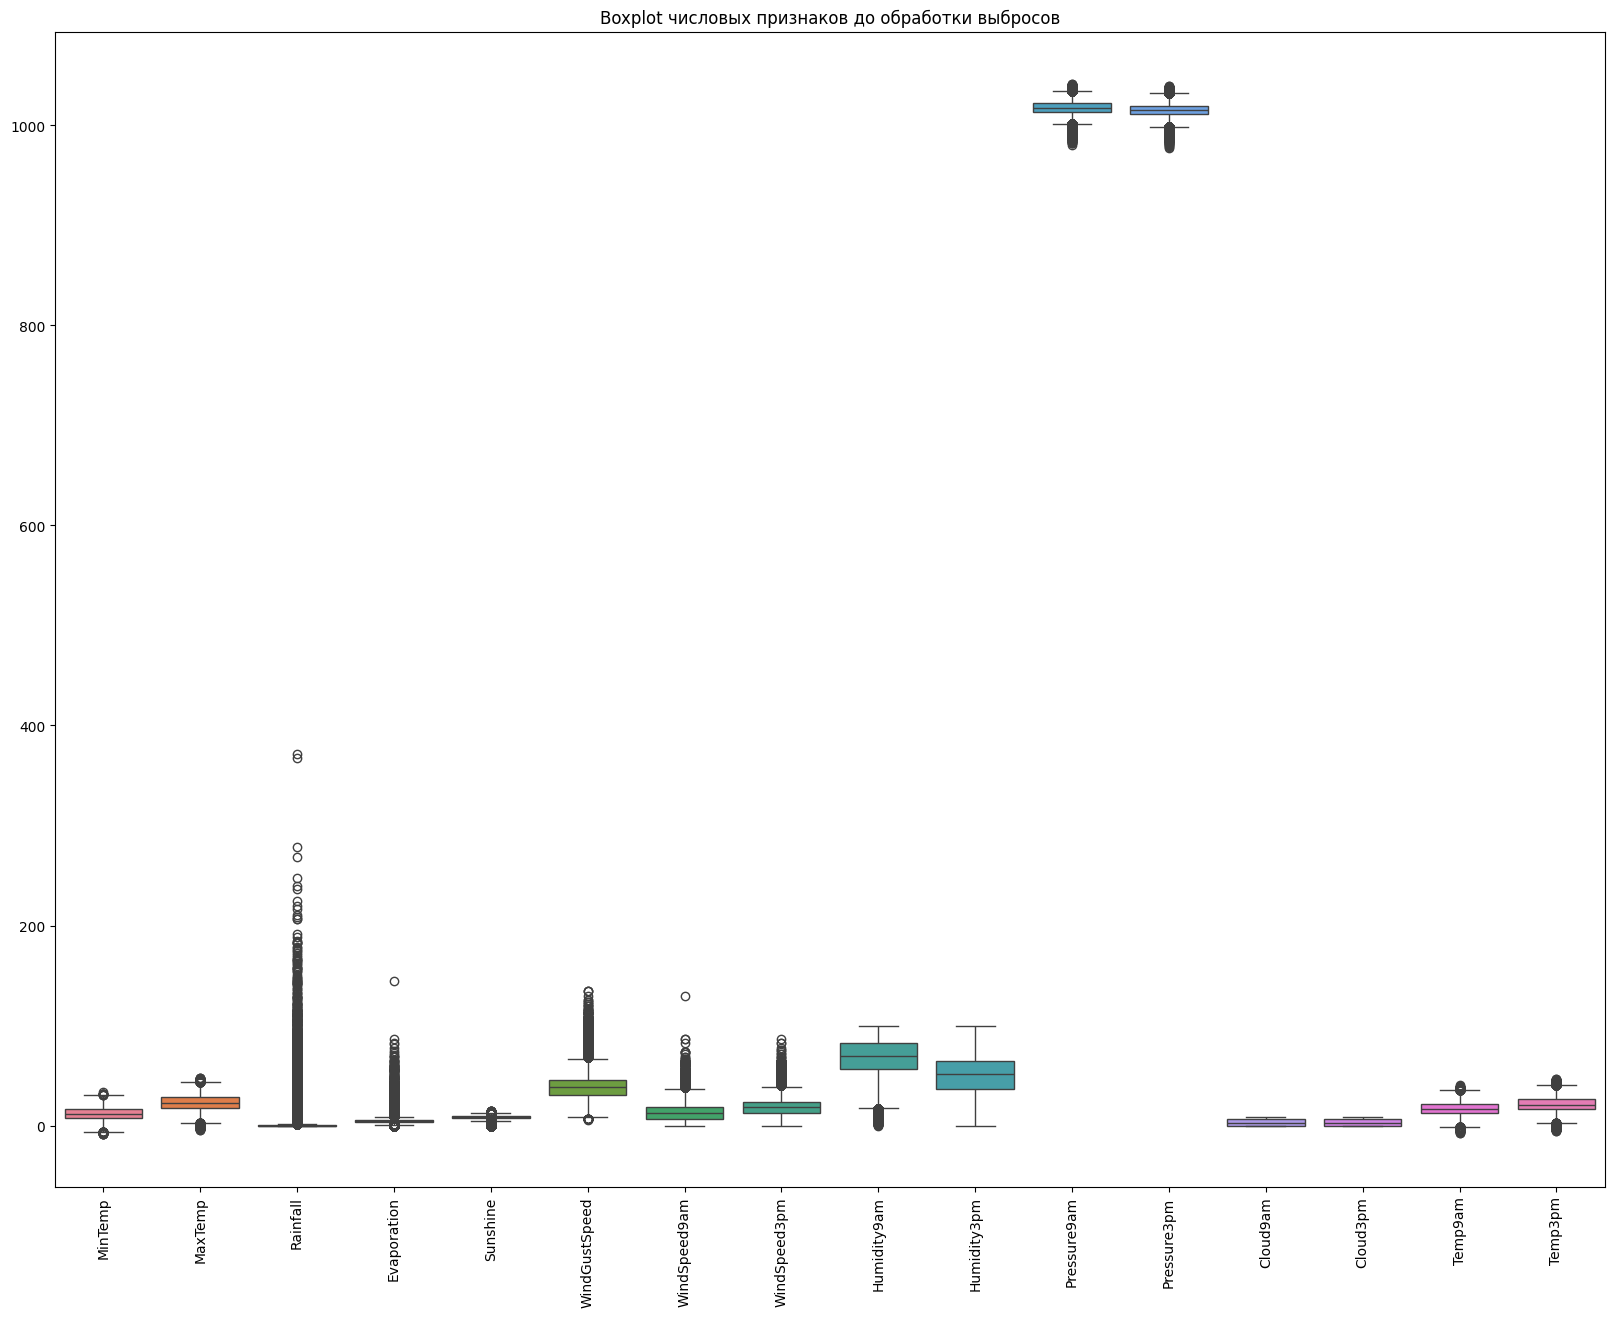

In [19]:
# Список числовых признаков
num_cols = data.select_dtypes(include=['float64']).columns
# Визуализация boxplot до обработки
plt.figure(figsize=(20,15))
sns.boxplot(data=data[num_cols])
plt.xticks(rotation=90)
plt.title("Boxplot числовых признаков до обработки выбросов")
plt.show()

*Сначала обработаем выбросы методом IQR для признаков, показывающих состояние в фиксированный момент времени суток, с возможными ошибками измерений: `Pressure9am`, `Pressure3pm`, `Humidity9am`, `Humidity3pm`,`Temp9am`, `Temp3pm`, `WindSpeed9am`, `WindSpeed3pm`.*

*Такие признаки, как `MinTemp`, `MaxTemp`, `WindGustSpeed` отражают реальные экстремумы погоды. Полностью обрабатывать их по IQR возможно не очень правильно, но по графикам видно, что количество выбросов небольшое относительно размера датасета, поэтому для них я также использую IQR.*

**Изменение:** при внимательном анализе перечисленных выше признаков распределений видно, что почти все выбросы находятся близко к границам и представляют собой реальные, возможные значения (например, высокая температура или давление). Поэтому я решила не применять метод IQR для этих признаков, так как это приведёт к искусственной обрезке вероятно корректных данных. Вручную уберу только отдельные выбросы в признаках `WindSpeed9am`, `WindSpeed3pm`.



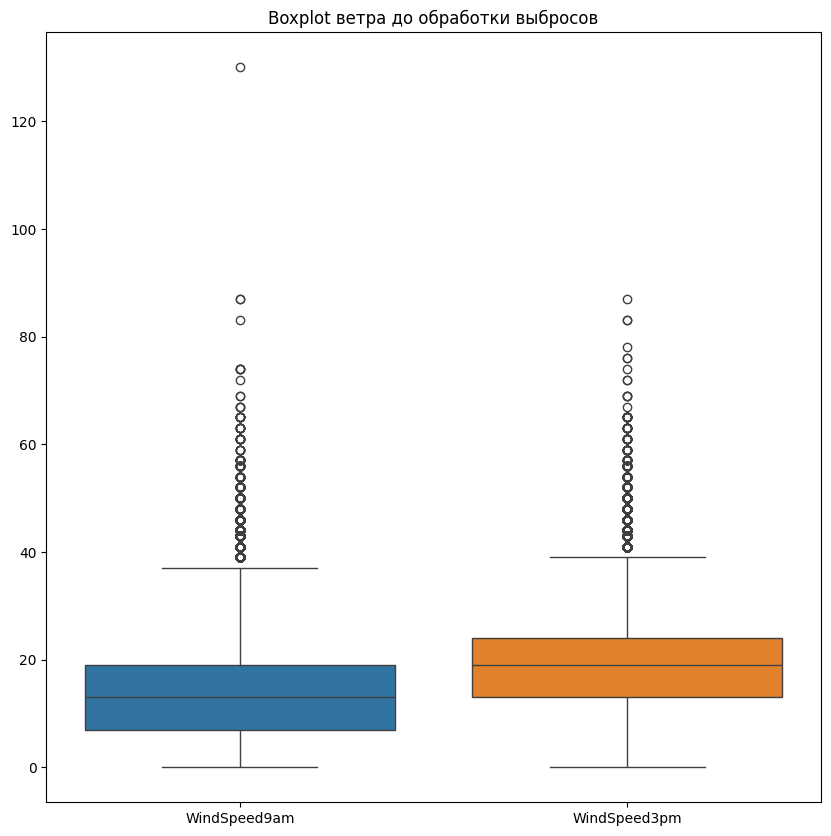

In [20]:
# Список признаков
# cols_to_cap = ['Pressure9am', 'Pressure3pm', 'Humidity9am',
#               'Humidity3pm', 'Temp9am', 'Temp3pm', 'MinTemp',
#               'MaxTemp', 'WindSpeed9am', 'WindSpeed3pm', 'WindGustSpeed']

# Визуализация boxplot до обработки
# Графики давления
# plt.figure(figsize=(10,5))
# sns.boxplot(data=data[['Pressure9am', 'Pressure3pm']])
# plt.title("Boxplot давления до обработки выбросов")
# plt.show()
# Графики влажности
# plt.figure(figsize=(10,5))
# sns.boxplot(data=data[['Humidity9am', 'Humidity3pm']])
# plt.title("Boxplot влажности до обработки выбросов")
# plt.show()
# Графики температуры
# plt.figure(figsize=(10,10))
# sns.boxplot(data=data[['Temp9am', 'Temp3pm', 'MinTemp', 'MaxTemp']])
# plt.title("Boxplot температуры до обработки выбросов")
# plt.show()

# Графики ветра
plt.figure(figsize=(10,10))
sns.boxplot(data=data[['WindSpeed9am', 'WindSpeed3pm']])
plt.title("Boxplot ветра до обработки выбросов")
plt.show()



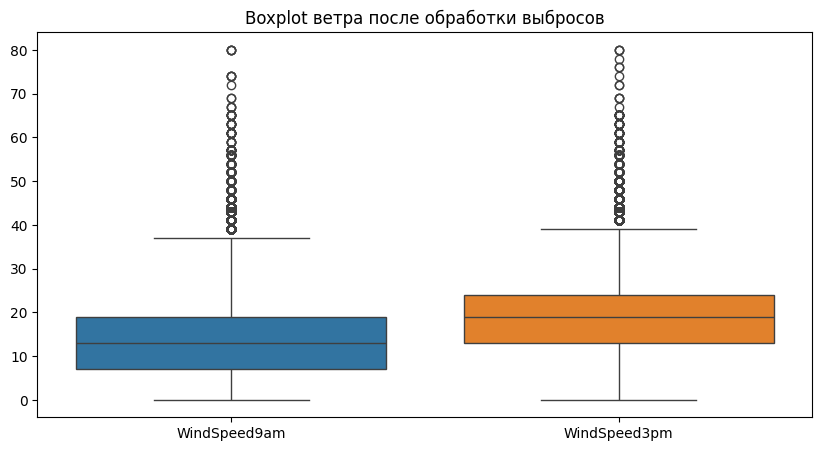

In [21]:
# Функция для обработки выбросов методом IQR
# def cap_outliers(df, column):
#    Q1 = df[column].quantile(0.25)
#    Q3 = df[column].quantile(0.75)
#    IQR = Q3 - Q1
#    lower_bound = Q1 - 1.5 * IQR
#    upper_bound = Q3 + 1.5 * IQR
    # Заменяем значения ниже/выше границ на границы
#    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)

# Обрабатываем выбросы
# for col in cols_to_cap:
#    cap_outliers(data, col)

# Визуализация boxplot после обработки
# Графики давления
# plt.figure(figsize=(10,5))
# sns.boxplot(data=data[['Pressure9am', 'Pressure3pm']])
# plt.title("Boxplot давления после обработки выбросов")
# plt.show()
# Графики влажности
# plt.figure(figsize=(10,5))
# sns.boxplot(data=data[['Humidity9am', 'Humidity3pm']])
# plt.title("Boxplot влажности после обработки выбросов")
# plt.show()
# Графики температуры
# plt.figure(figsize=(10,5))
# sns.boxplot(data=data[['Temp9am', 'Temp3pm', 'MinTemp', 'MaxTemp']])
# plt.title("Boxplot температуры после обработки выбросов")
# plt.show()

# Обрезка (границы подбираю по графику)
WindSpeed9am_cap = 80
WindSpeed3pm_cap = 80

data['WindSpeed9am'] = data['WindSpeed9am'].clip(upper=WindSpeed9am_cap)
data['WindSpeed3pm'] = data['WindSpeed3pm'].clip(upper=WindSpeed3pm_cap)

# Графики ветра
plt.figure(figsize=(10,5))
sns.boxplot(data=data[['WindSpeed9am', 'WindSpeed3pm']])
plt.title("Boxplot ветра после обработки выбросов")
plt.show()


Для признака `Rainfall`, в котором слишком большое число экстремальных значений, я вручную обрежу данные, чтобы убрать аномальные записи, но сохранить важные показатели.

Также сделаю с `Evaporation`, чтобы не терять имеющиеся показатели, так как 43% данных итак были заполнены медианой. По этой же причине не удаляю выбросы в `Sunshine`.

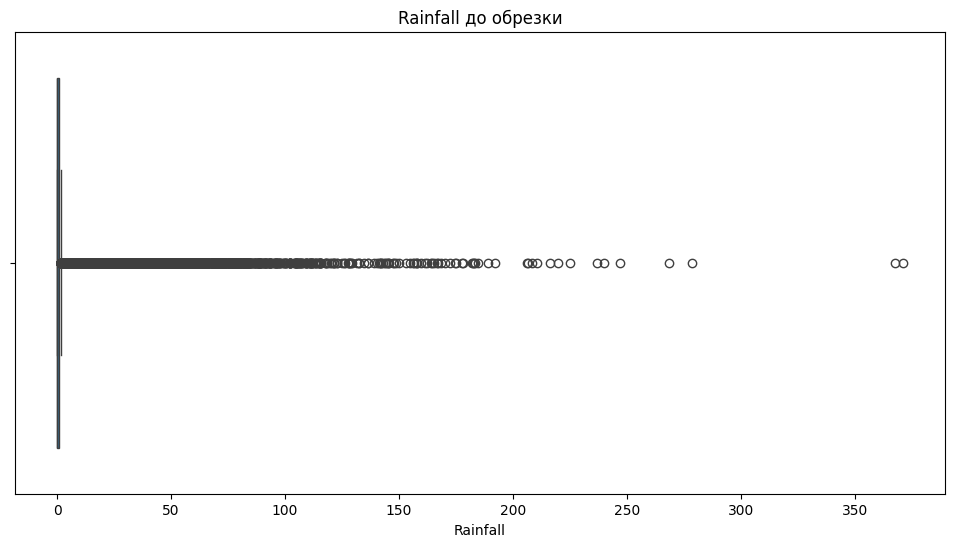

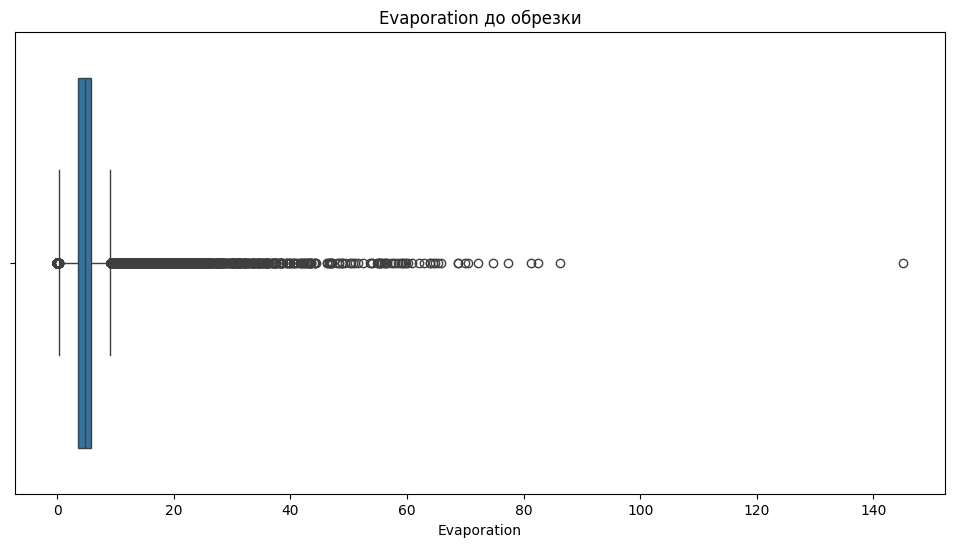

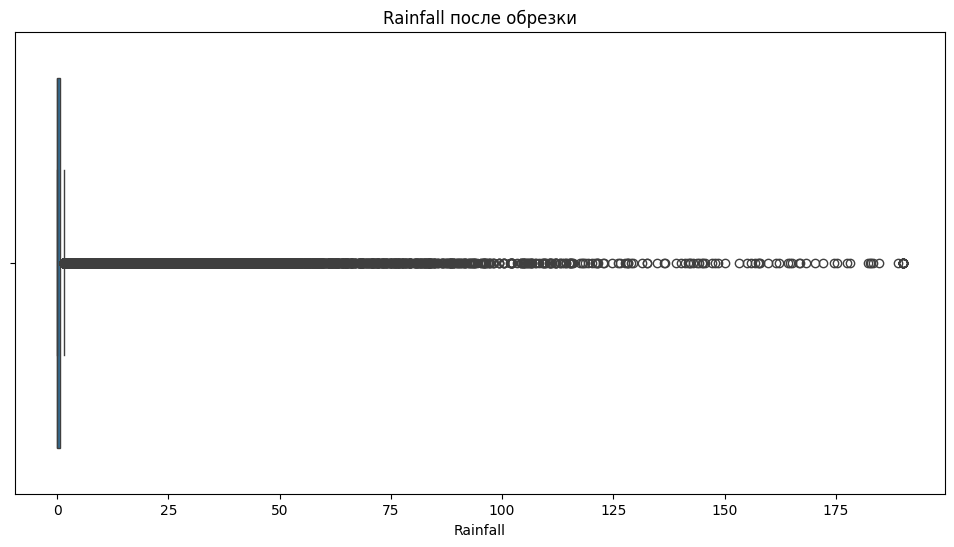

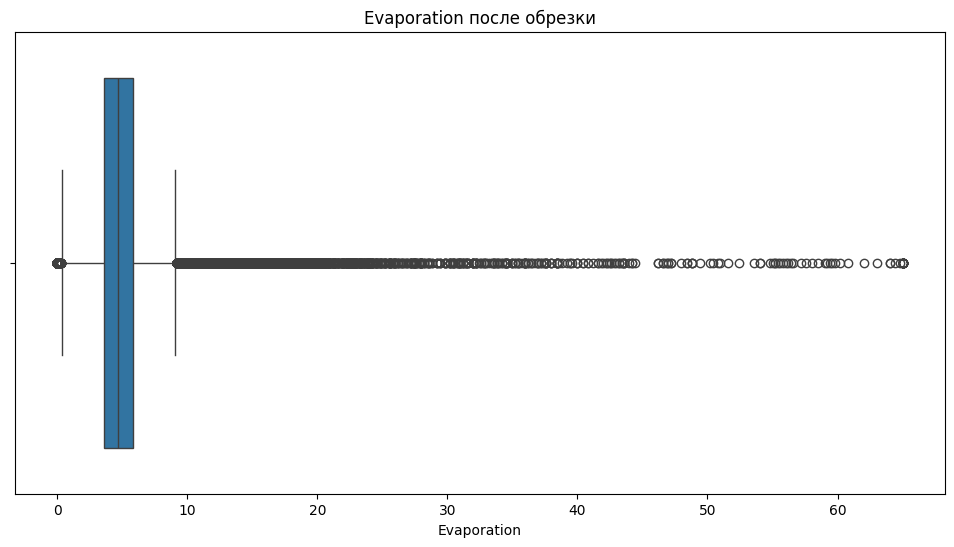

In [22]:
# Смотрим распределение
plt.figure(figsize=(12,6))
sns.boxplot(x=data['Rainfall'])
plt.title("Rainfall до обрезки")
plt.show()

plt.figure(figsize=(12,6))
sns.boxplot(x=data['Evaporation'])
plt.title("Evaporation до обрезки")
plt.show()

# Обрезка (границы подбираю по графику)
rainfall_cap = 190
evaporation_cap = 65

data['Rainfall'] = data['Rainfall'].clip(upper=rainfall_cap)
data['Evaporation'] = data['Evaporation'].clip(upper=evaporation_cap)

# После обрезки
plt.figure(figsize=(12,6))
sns.boxplot(x=data['Rainfall'])
plt.title("Rainfall после обрезки")
plt.show()

plt.figure(figsize=(12,6))
sns.boxplot(x=data['Evaporation'])
plt.title("Evaporation после обрезки")
plt.show()

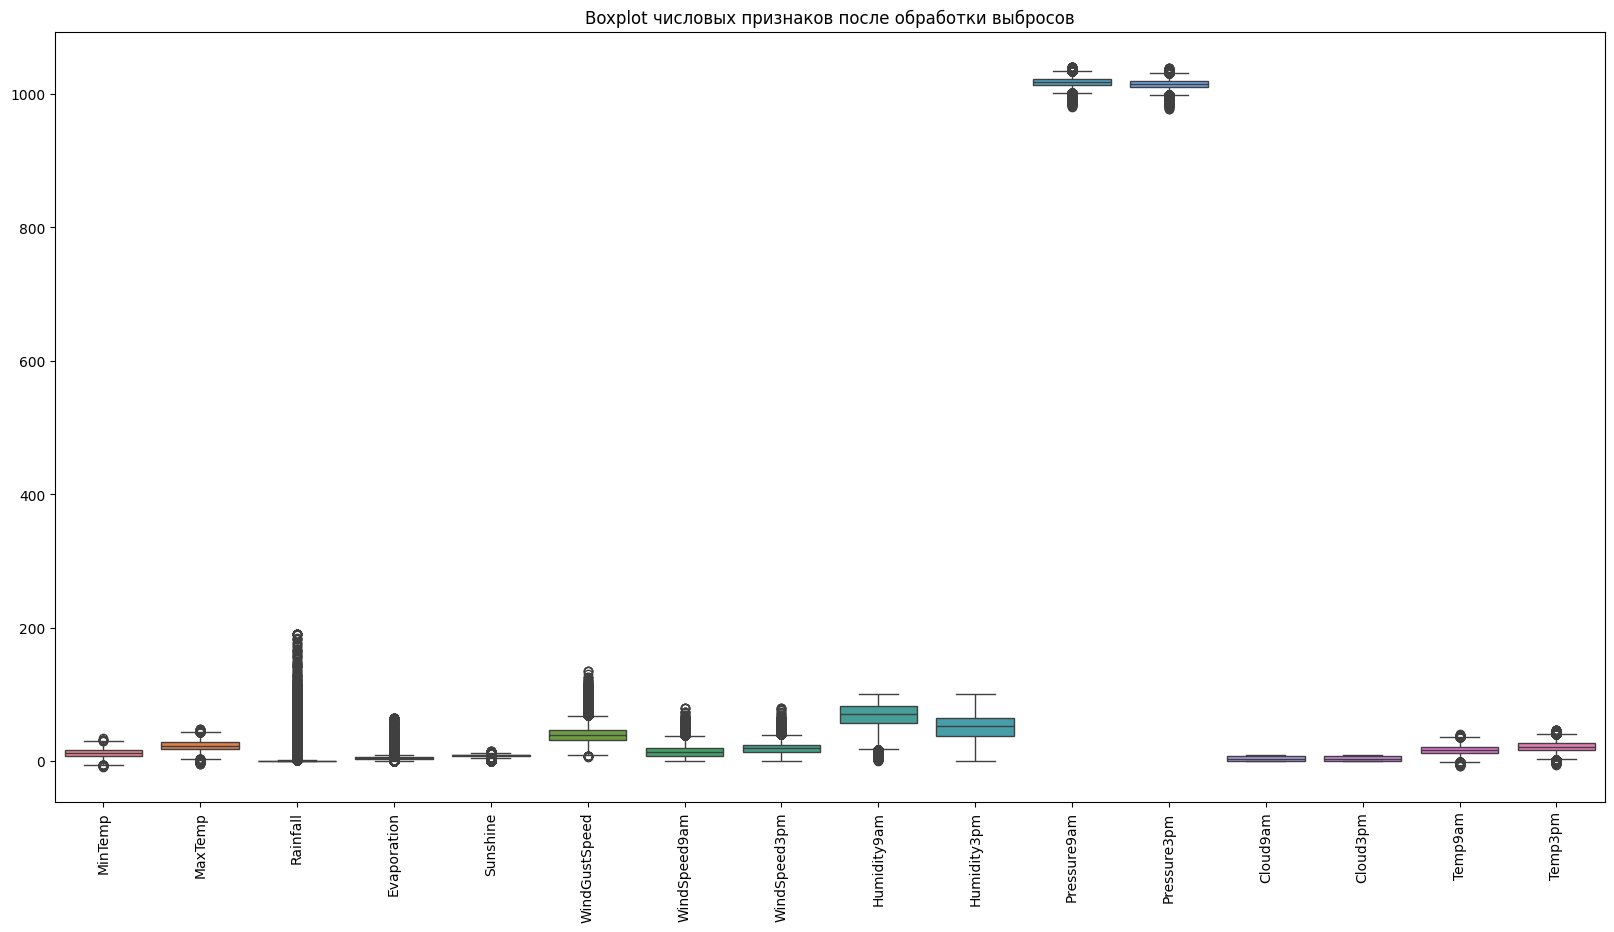

In [23]:
# Визуализация boxplot после обработки
plt.figure(figsize=(20,10))
sns.boxplot(data=data[num_cols])
plt.xticks(rotation=90)
plt.title("Boxplot числовых признаков после обработки выбросов")
plt.show()

Данные обработаны от выбросов.

## 4. Обработка неправильного типа данных

Столбец Date ранее уже был преобразован в формат даты datetime. Теперь нужно категориальные признаки преобразовать в категориальный тип. Это улучшает работу с данными и экономит память.

In [24]:
# Преобразуем категориальные признаки
categorical_cols = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow']
for col in categorical_cols:
    data[col] = data[col].astype('category')

# Проверяем результат
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 142193 entries, 0 to 145458
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           142193 non-null  datetime64[ns]
 1   Location       142193 non-null  category      
 2   MinTemp        142193 non-null  float64       
 3   MaxTemp        142193 non-null  float64       
 4   Rainfall       142193 non-null  float64       
 5   Evaporation    142193 non-null  float64       
 6   Sunshine       142193 non-null  float64       
 7   WindGustDir    142193 non-null  category      
 8   WindGustSpeed  142193 non-null  float64       
 9   WindDir9am     142193 non-null  category      
 10  WindDir3pm     142193 non-null  category      
 11  WindSpeed9am   142193 non-null  float64       
 12  WindSpeed3pm   142193 non-null  float64       
 13  Humidity9am    142193 non-null  float64       
 14  Humidity3pm    142193 non-null  float64       
 15  Press

Все данные приведены к нужному типу.

## 5. Преобразование качественных признаков

Признаки `RainToday` и `RainTomorrow` являются булевыми (дождь был / не был).  
- `RainToday` показывает, был ли дождь сегодня (1) или нет (0).  
- `RainTomorrow` — целевая переменная, показывает, будет ли дождь завтра (1) или нет (0).  

Для таких признаков достаточно перевести значения в числа 0 и 1 с помощью Label Encoding. Это упрощает данные и сразу делает их пригодными для анализа и обучения моделей.

In [25]:
# Преобразование булевых признаков в числовые
data['RainToday'] = data['RainToday'].cat.codes
data['RainTomorrow'] = data['RainTomorrow'].cat.codes

data[['RainToday', 'RainTomorrow']].head(10)

,RainToday,RainTomorrow
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,1
9,1,0


Признаки направления ветра (`WindGustDir`, `WindDir9am`, `WindDir3pm`) нужно закодировать методом One-Hot Encoding. Каждый уникальный вариант направления ветра станет отдельным бинарным столбцом (1 — если направление совпадает, 0 — иначе). Это позволяет моделям правильно обрабатывать категориальные признаки без введения ложного порядка.

Признак `Location` нужно закодировать аналогично, хотя он имеет большое количество уникальных значений (49) и так как для моделей типа случайного леса или дерева решений Label Encoding корректен, возможно можно было оставить его без One-Hot кодирования.


In [26]:
# Создаю копию датасета
data_encoded = data.copy()

# Список категориальных признаков для one-hot кодирования
categorical_features = ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'Location']

# One-hot кодирование
data_encoded = pd.get_dummies(data_encoded, columns=categorical_features, drop_first=True)

data_encoded.head(10)

,Date,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,...,Location_Townsville,Location_Tuggeranong,Location_Uluru,Location_WaggaWagga,Location_Walpole,Location_Watsonia,Location_Williamtown,Location_Witchcliffe,Location_Wollongong,Location_Woomera
0,2008-12-01,13.4,22.9,0.6,4.7,8.6,44.0,20.0,24.0,71.0,...,False,False,False,False,False,False,False,False,False,False
1,2008-12-02,7.4,25.1,0.0,4.7,8.6,44.0,4.0,22.0,44.0,...,False,False,False,False,False,False,False,False,False,False
2,2008-12-03,12.9,25.7,0.0,4.7,8.6,46.0,19.0,26.0,38.0,...,False,False,False,False,False,False,False,False,False,False
3,2008-12-04,9.2,28.0,0.0,4.7,8.6,24.0,11.0,9.0,45.0,...,False,False,False,False,False,False,False,False,False,False
4,2008-12-05,17.5,32.3,1.0,4.7,8.6,41.0,7.0,20.0,82.0,...,False,False,False,False,False,False,False,False,False,False
5,2008-12-06,14.6,29.7,0.2,4.7,8.6,56.0,19.0,24.0,55.0,...,False,False,False,False,False,False,False,False,False,False
6,2008-12-07,14.3,25.0,0.0,4.7,8.6,50.0,20.0,24.0,49.0,...,False,False,False,False,False,False,False,False,False,False
7,2008-12-08,7.7,26.7,0.0,4.7,8.6,35.0,6.0,17.0,48.0,...,False,False,False,False,False,False,False,False,False,False
8,2008-12-09,9.7,31.9,0.0,4.7,8.6,80.0,7.0,28.0,42.0,...,False,False,False,False,False,False,False,False,False,False
9,2008-12-10,13.1,30.1,1.4,4.7,8.6,28.0,15.0,11.0,58.0,...,False,False,False,False,False,False,False,False,False,False


Все признаки приведены к нужному виду.

**Изменеия:** one-hot кодирование приводит к значительному увеличению признаков, что значительно замедляет вычисления, поэтому для последующей работы с моделями логистической регрессии и SVM я решила удалить основную часть признаков, требующих one-hot кодирование и оставить только Location, так как этот признак сильнее всего влияет на целевую переменную. Остальные признаки тоже имеют влияние на целевой признак, хотя и меньшее, поэтому метрики моделей после этого несколько ухудшатся.

In [27]:
# Создаем копию исходных данных для анализа важности категориальных признаков
data_cat_check = data.copy()

# Список категориальных признаков
categorical_features = ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'Location']

# Словарь для хранения корреляции с целевой переменной
cat_corr = {}

for col in categorical_features:
    # Для категориального признака получаем среднее значение целевой переменной для каждого уровня
    mean_target = data_cat_check.groupby(col)['RainTomorrow'].mean()
    # Разница между максимумом и минимумом среднего значения целевой переменной показывает влияние
    influence = mean_target.max() - mean_target.min()
    cat_corr[col] = influence

# Сортируем по влиянию
cat_corr = dict(sorted(cat_corr.items(), key=lambda x: x[1], reverse=True))
cat_corr


/tmp/ipython-input-444731352.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_target = data_cat_check.groupby(col)['RainTomorrow'].mean()


{'Location': 0.2979287879938022,
 'WindDir9am': 0.1642264618613403,
 'WindGustDir': 0.13656704884935045,
 'WindDir3pm': 0.11315465335357588}

In [36]:
# Создаём копию датасета для SVM
data_encoded2 = data.copy()

# Удаляем признаки направления ветра
drop_features = ['WindDir9am', 'WindGustDir', 'WindDir3pm']
data_encoded2 = data_encoded2.drop(columns=drop_features)

# One-hot кодирование только для Location
data_encoded2 = pd.get_dummies(data_encoded2, columns=['Location'], drop_first=True)

# Проверим результат
print("Форма датасета после преобразования:", data_encoded2.shape)
data_encoded2.head()


Форма датасета после преобразования: (142193, 67)


,Date,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,...,Location_Townsville,Location_Tuggeranong,Location_Uluru,Location_WaggaWagga,Location_Walpole,Location_Watsonia,Location_Williamtown,Location_Witchcliffe,Location_Wollongong,Location_Woomera
0,2008-12-01,13.4,22.9,0.6,4.7,8.6,44.0,20.0,24.0,71.0,...,False,False,False,False,False,False,False,False,False,False
1,2008-12-02,7.4,25.1,0.0,4.7,8.6,44.0,4.0,22.0,44.0,...,False,False,False,False,False,False,False,False,False,False
2,2008-12-03,12.9,25.7,0.0,4.7,8.6,46.0,19.0,26.0,38.0,...,False,False,False,False,False,False,False,False,False,False
3,2008-12-04,9.2,28.0,0.0,4.7,8.6,24.0,11.0,9.0,45.0,...,False,False,False,False,False,False,False,False,False,False
4,2008-12-05,17.5,32.3,1.0,4.7,8.6,41.0,7.0,20.0,82.0,...,False,False,False,False,False,False,False,False,False,False


## 6. Деление на тренировочную, тестовую и валидационную выборки.

Разделим на выборки в пропорции 70%/15%/15%.

Train (тренировочная) — на ней модель учится, подбирает параметры.

Validation (валидационная) — проверка гиперпараметров, настройка модели, чтобы не переобучилась на тренировочные данные.

Test (тестовая) — финальная проверка качества модели, данные не использовались ни для обучения, ни для валидации.

In [38]:
# Отделяем признаки (X) и целевую переменную (y)
X = data_encoded2.drop(columns=['RainTomorrow'])  # все колонки кроме целевой
y = data_encoded2['RainTomorrow']

# Сначала делим на тренировочную и временную
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Потом временную делим на валидационную и тестовую
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Проверим размеры
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (99535, 66) (99535,)
Validation: (21329, 66) (21329,)
Test: (21329, 66) (21329,)


## 7. Стандартизация числовых признаков

Для корректной работы многих моделей машинного обучения необходимо привести числовые признаки к одному масштабу. Без этого признаки с большими значениями могут перевешивать признаки с меньшими значениями.



In [39]:
# Выбираем числовые признаки для стандартизации
numeric_features = X_train.select_dtypes(include=['float64', 'int64']).columns

# Создаем копии датасетов
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

# Создаём объект стандартизатора
scaler = StandardScaler()

# Обучаем стандартизатор на train (считает среднее и отклонение) и применяем к train, val, test
X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_val_scaled[numeric_features] = scaler.transform(X_val[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

# Проверим размеры
print("Train:", X_train_scaled.shape)
print("Validation:", X_val_scaled.shape)
print("Test:", X_test_scaled.shape)

# Проверим, что среднее ~0 и стандартное отклонение ~1 на train
print("\nПроверка стандартизации (train):")
print("Среднее по числовым признакам:\n", X_train_scaled[numeric_features].mean().round(2))
print("Станд. отклонение по числовым признакам:\n", X_train_scaled[numeric_features].std().round(2))


Train: (99535, 66)
Validation: (21329, 66)
Test: (21329, 66)

Проверка стандартизации (train):
Среднее по числовым признакам:
 MinTemp         -0.0
MaxTemp         -0.0
Rainfall        -0.0
Evaporation     -0.0
Sunshine         0.0
WindGustSpeed    0.0
WindSpeed9am     0.0
WindSpeed3pm     0.0
Humidity9am     -0.0
Humidity3pm     -0.0
Pressure9am     -0.0
Pressure3pm     -0.0
Cloud9am         0.0
Cloud3pm        -0.0
Temp9am         -0.0
Temp3pm         -0.0
dtype: float64
Станд. отклонение по числовым признакам:
 MinTemp          1.0
MaxTemp          1.0
Rainfall         1.0
Evaporation      1.0
Sunshine         1.0
WindGustSpeed    1.0
WindSpeed9am     1.0
WindSpeed3pm     1.0
Humidity9am      1.0
Humidity3pm      1.0
Pressure9am      1.0
Pressure3pm      1.0
Cloud9am         1.0
Cloud3pm         1.0
Temp9am          1.0
Temp3pm          1.0
dtype: float64


Теперь все числовые признаки сравнимы между собой и имеют один и тот же масштаб. Категориальные признаки не трогали, они закодированы отдельно (one-hot или 0/1). Размеры выборок остались прежними, значит никакие данные не потеряны.

## 8. Визуализация

### Гистограммы числовых признаков

Здесь показано распределение всех числовых признаков датасета после стандартизации. Гистограмма позволяет увидеть форму распределения: нормальное, скошенное, с длинными хвостами. Это важно для понимания, какие признаки могут требовать трансформации или особой обработки при моделировании.


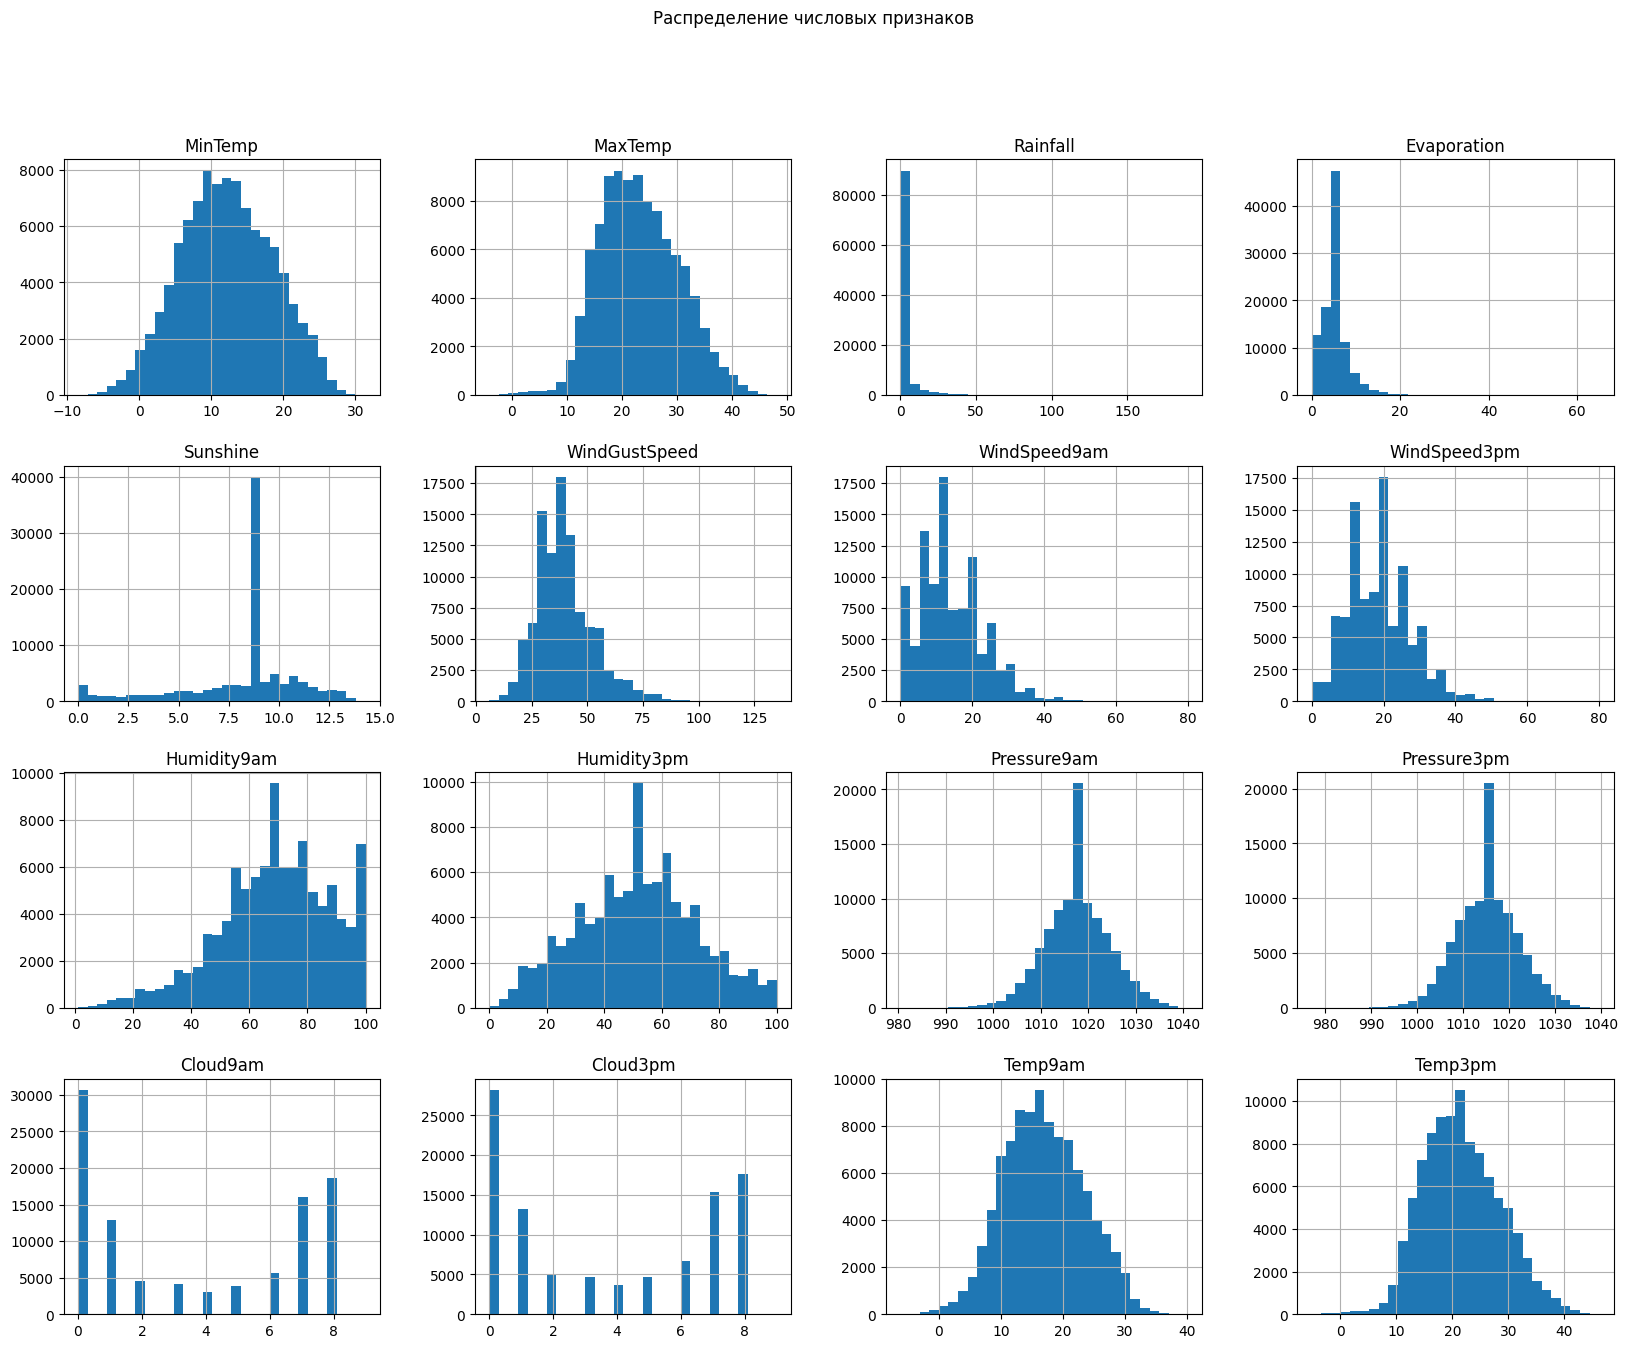

In [30]:
numeric_features = X_train.select_dtypes(include=['float64', 'int64']).columns
X_train[numeric_features].hist(bins=30, figsize=(20, 15))
plt.suptitle("Распределение числовых признаков")
plt.show()

Большинство признаков примерно симметричны после стандартизации. Некоторые имеют центральный пик, что соответствует частым значениям. Например, Rainfall=0 (отсутствие дождя). Данные с таким распределением содержат много повторяющихся значений, что стоит учитывать при дальнейшем моделировании.  

У признаков `Evaporation` и `Sunshine` видно, что после заполнения большого числа пропусков медианой на гистограммах появился высокий пик в определенном значении. Аналогично с `Pressure9am`	и `Pressure3pm`, но пик поменьше.


### Корреляционная матрица числовых признаков

Матрица показывает линейные зависимости между числовыми признаками.  
- Корреляция варьируется от -1 до 1.  
- Сильная положительная или отрицательная корреляция может указывать на мультиколлинеарность, что важно учитывать при некоторых моделях.


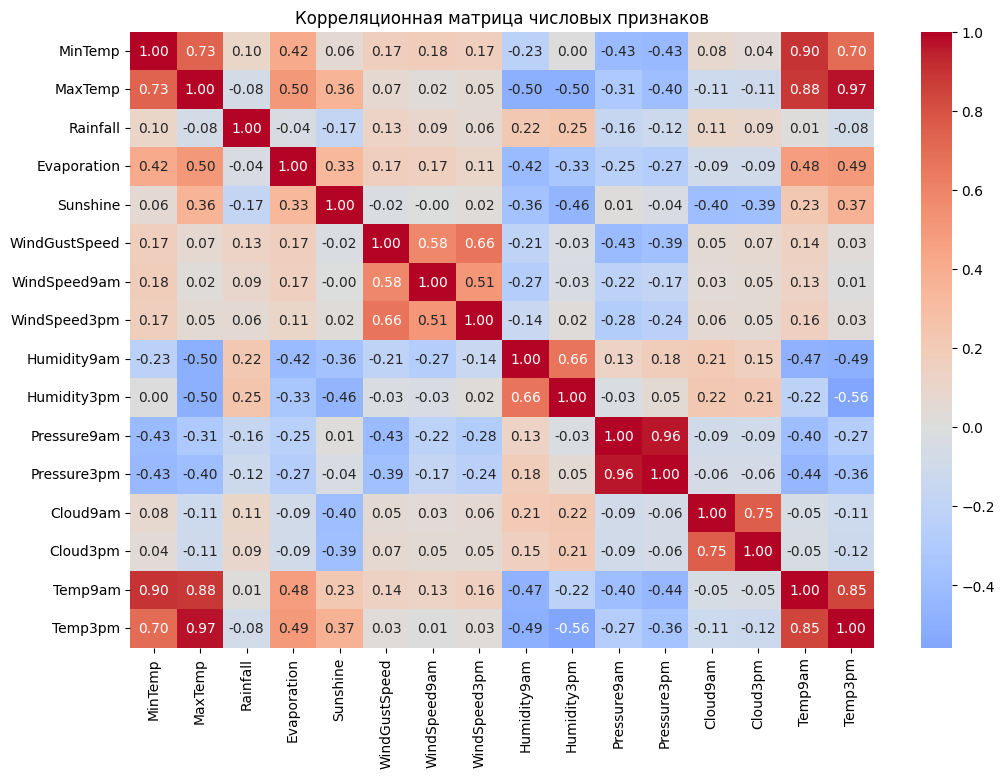

In [31]:
plt.figure(figsize=(12, 8))
corr_matrix = X_train[numeric_features].corr()
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Корреляционная матрица числовых признаков")
plt.show()

Видно, что очень сильно положительно коррелируют схожие показатели, вроде температуры (MinTemp, MaxTemp, Temp9am, Temp3pm), ветра (WindGustSpeed, WindSpeed9am, WindSpeed3pm), давления (Pressure9am, Pressure3pm) и другие схожие признаки, отличающиеся только временем измерения. Эти связи могут быть полезны для выбора признаков или построения новых.

Целевая переменная RainTomorrow — бинарный признак, поэтому можно использовать точечную корреляцию (Point Biserial Correlation), чтобы посмотреть, какие числовые признаки сильнее связаны с дождём завтра.

In [32]:
corr_with_target = X_train[numeric_features].apply(lambda x: x.corr(y_train))
corr_with_target.sort_values(ascending=False)


,0
Humidity3pm,0.438510
Humidity9am,0.254409
Rainfall,0.234569
WindGustSpeed,0.224189
Cloud3pm,0.176775
Cloud9am,0.157814
WindSpeed9am,0.092715
WindSpeed3pm,0.088141
MinTemp,0.082980
Temp9am,-0.026771


### Баланс классов (RainTomorrow)

График показывает количество случаев с дождём и без дождя на следующий день.


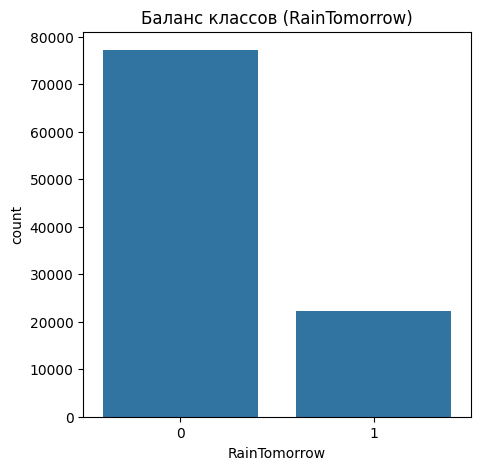

In [33]:
plt.figure(figsize=(5, 5))
sns.countplot(x=y_train)
plt.title("Баланс классов (RainTomorrow)")
plt.show()


Дождь завтра встречается реже, чем отсутствие дождя.

### Распределение категориальных признаков

Можно также посмотреть, как изначально были распределены категориальные данные до их кодирования, то есть сколько раз встречается каждая категория в категориальных признаках (`Location`, `WindGustDir`, `WindDir9am`, `WindDir3pm`).

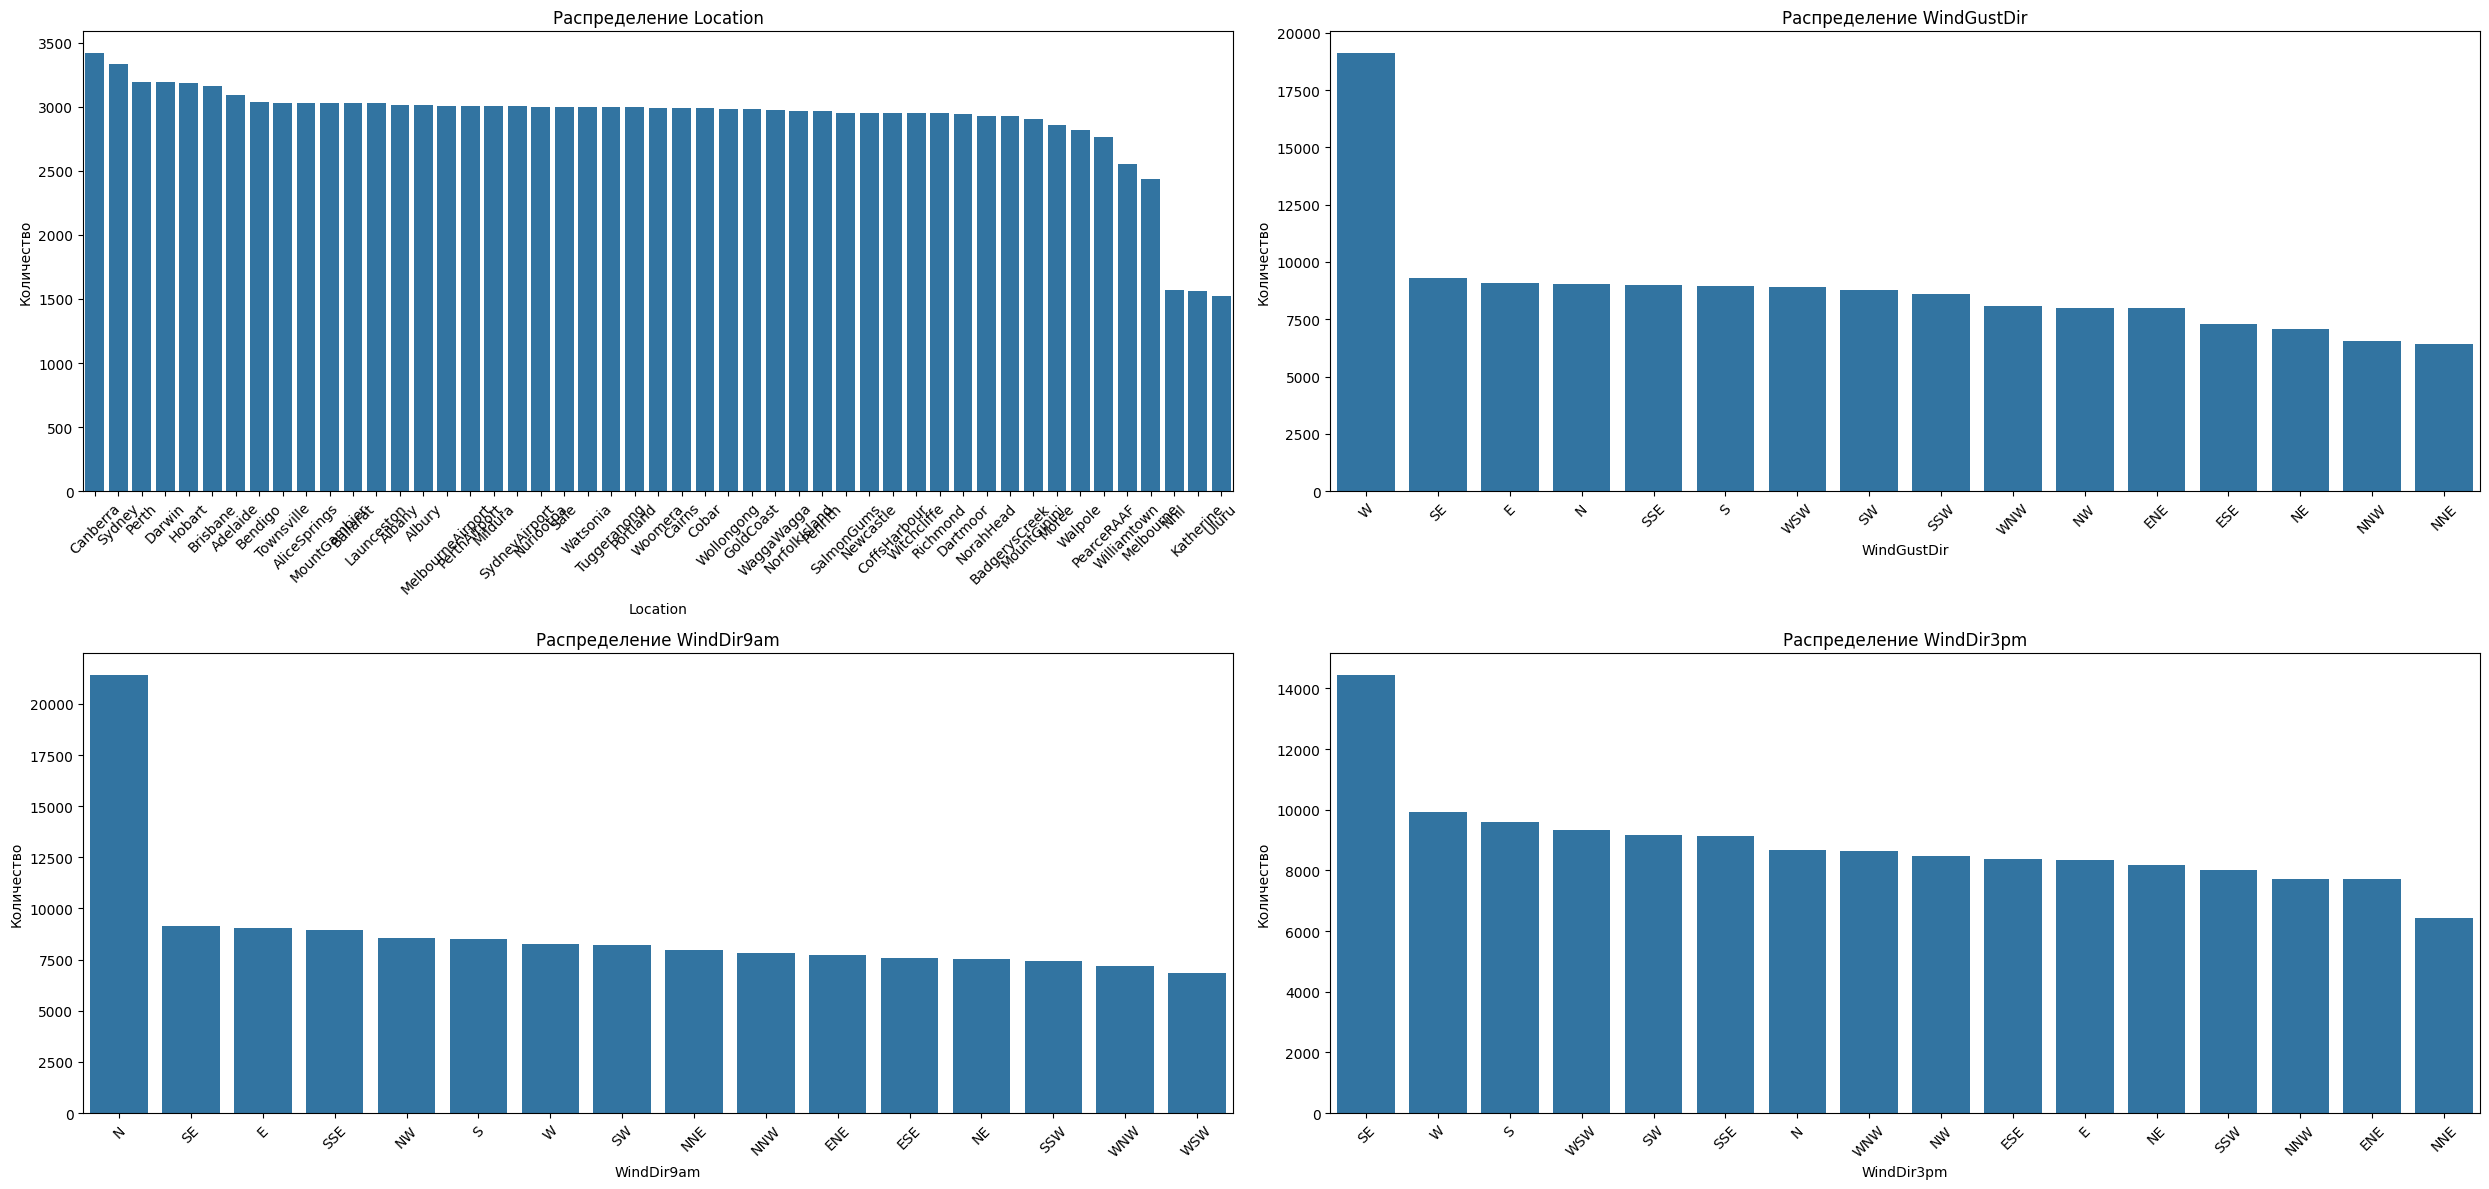

In [34]:
categorical_features = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm']

plt.figure(figsize=(25, 12))
for i, feature in enumerate(categorical_features, 1):
    plt.subplot(2, 2, i)
    sns.countplot(x=data[feature], order=data[feature].value_counts().index)
    plt.title(f'Распределение {feature}')
    plt.xlabel(feature)
    plt.ylabel('Количество')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Общий вывод

В ходе выполнения работы был проведён первичный анализ данных на примере датасета Rain in Australia. Были выполнены все поставленные задачи. Для описания датасета были применены разные методы анализа, что помогло комплексно изучить структуру и качество данных. Проведённая предобработка данных позволила привести датасет к удобному и корректному для дальнейшего анализа и моделирования виду. Данные очищены от пропусков и выбросов, все признаки приведены к подходящему формату, категориальные переменные закодированы, а числовые стандартизированы. Таким образом, задача первичного анализа и подготовки данных выполнена, полученный датасет готов к применению методов машинного обучения.

Сохранение данных для последущей работы:

In [42]:
import joblib
from google.colab import files

joblib.dump((X_train_scaled, y_train), "train.pkl")
joblib.dump((X_val_scaled, y_val), "val.pkl")
joblib.dump((X_test_scaled, y_test), "test.pkl")

files.download("train.pkl")
files.download("val.pkl")
files.download("test.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>